In [1]:
import urllib.request
import gzip
import shutil
import os

# 1. Provide the URL and the target filenames
url = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.vi.300.vec.gz"  # Replace with your actual URL
compressed_file = "cc.vi.300.vec.gz"
extracted_file = "cc.vi.300.vec"

# 2. Download the file (Equivalent to 'wget')
print(f"Downloading {compressed_file}...")
urllib.request.urlretrieve(url, compressed_file)
print("Download completed.")

# 3. Extract the gzip file (Equivalent to 'gunzip')
print(f"Extracting {compressed_file}...")
with gzip.open(compressed_file, 'rb') as f_in:
    with open(extracted_file, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
        
print("Extraction completed. You can delete the .gz file if you want.")

#Optional: delete the compressed .gz file after extracting
os.remove(compressed_file)


Download completed.
Extracting cc.vi.300.vec.gz...
Extraction completed. You can delete the .gz file if you want.


In [8]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from pyvi import ViTokenizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout, SpatialDropout1D, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time 

# 1. Khai báo đường dẫn và Đọc dữ liệu
train_path = r"c:\Users\ADMIN\Documents\Chuyen Nganh\HK2\Nhập môn học máy\Lab1-ML\ML-Lab1-Restaurant\dataset\model data\train.csv"
val_path = r"c:\Users\ADMIN\Documents\Chuyen Nganh\HK2\Nhập môn học máy\Lab1-ML\ML-Lab1-Restaurant\dataset\model data\val.csv"
test_path = r"c:\Users\ADMIN\Documents\Chuyen Nganh\HK2\Nhập môn học máy\Lab1-ML\ML-Lab1-Restaurant\dataset\model data\test.csv"

train_df = pd.read_csv(train_path).dropna()
val_df = pd.read_csv(val_path).dropna()
test_df = pd.read_csv(test_path).dropna()

# =========================================================================
# 2. THỐNG NHẤT TIỀN XỬ LÝ (WORD SEGMENTATION VỚI PYVI)
# =========================================================================
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'([.,!?()])', r' \1 ', text) # Tách dấu câu
    text = ViTokenizer.tokenize(text) # Gom từ ghép: "nhà hàng" -> "nhà_hàng"
    return text

print("⏳ Đang thực hiện Word Segmentation...")
X_train_raw = train_df['review'].apply(preprocess).values
X_val_raw = val_df['review'].apply(preprocess).values
X_test_raw = test_df['review'].apply(preprocess).values

y_train = train_df['label'].values
y_val = val_df['label'].values
y_test = test_df['label'].values

# =========================================================================
# 3. TÍNH CLASS WEIGHTS (CHO LỆNH .FIT TRONG KERAS)
# =========================================================================
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))
print(f"📌 Class Weights chuẩn hóa: {class_weights_dict}")

# 4. TOKENIZATION & PADDING
MAX_VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 256 # Theo yêu cầu của bạn

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train_raw), maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_val_pad = pad_sequences(tokenizer.texts_to_sequences(X_val_raw), maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test_raw), maxlen=MAX_SEQUENCE_LENGTH, padding='post')

# =========================================================================
# 5. NẠP TRI THỨC "KNOWLEDGE" TỪ FASTTEXT (TRÁNH TRAIN TỪ CON SỐ 0)
# =========================================================================
def load_fasttext_matrix(filepath, word_index, embedding_dim):
    vocab_size = len(word_index) + 1
    matrix = np.zeros((vocab_size, embedding_dim))
    print(f"⏳ Đang nạp Embedding Matrix từ {filepath}...")
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            if word in word_index:
                idx = word_index[word]
                matrix[idx] = np.array(values[1:], dtype='float32')
    return matrix

EMBEDDING_DIM = 300 # FastText Vietnamese mặc định là 300D
embedding_matrix = load_fasttext_matrix('cc.vi.300.vec', tokenizer.word_index, EMBEDDING_DIM)

# =========================================================================
# 6. XÂY DỰNG MÔ HÌNH BIGRU 
# =========================================================================

model = Sequential([
    # Khai báo đầu vào rõ ràng ở đây (thay thế cho input_length)
    Input(shape=(MAX_SEQUENCE_LENGTH,)), 
    
    Embedding(input_dim=len(tokenizer.word_index) + 1, 
              output_dim=EMBEDDING_DIM, 
              weights=[embedding_matrix], 
              trainable=True), 
    
    SpatialDropout1D(0.3),
    Bidirectional(GRU(128, return_sequences=True)),
    Bidirectional(GRU(64)),
    
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax') 
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Callbacks: Theo dõi val_loss và dừng sớm nếu không cải thiện
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)


start_time = time.time() # Ghi lại thời điểm bắt đầu
# 7. HUẤN LUYỆN 
print("\nBắt đầu huấn luyện...")
history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20, 
    batch_size=16, 
    class_weight=class_weights_dict, 
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

end_time = time.time() # Ghi lại thời điểm kết thúc
training_duration = end_time - start_time
print(f"\nHoàn tất huấn luyện!")
print(f"Tổng thời gian huấn luyện: {training_duration/60:.2f} phút")


⏳ Đang thực hiện Word Segmentation...
📌 Class Weights chuẩn hóa: {0: 1.753786355716392, 1: 0.5504027593749343, 2: 1.6314444236643602}
⏳ Đang nạp Embedding Matrix từ cc.vi.300.vec...

Bắt đầu huấn luyện...
Epoch 1/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 196s 117ms/step - accuracy: 0.7120 - loss: 0.6451 - val_accuracy: 0.8404 - val_loss: 0.3730 - learning_rate: 0.0010
Epoch 2/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 190s 116ms/step - accuracy: 0.8346 - loss: 0.4030 - val_accuracy: 0.8560 - val_loss: 0.3237 - learning_rate: 0.0010
Epoch 3/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 191s 116ms/step - accuracy: 0.8691 - loss: 0.3212 - val_accuracy: 0.8343 - val_loss: 0.3817 - learning_rate: 0.0010
Epoch 4/20
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9020 - loss: 0.2382
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
1636/1636 ━━━━━━━━━━━━━━━━━━━━ 191s 117ms/step - accuracy: 0.8989 - loss: 0.2462 - val_accuracy: 0.8462 - val_loss: 0.3919 - learning_rate: 0.0010
Epoch 5

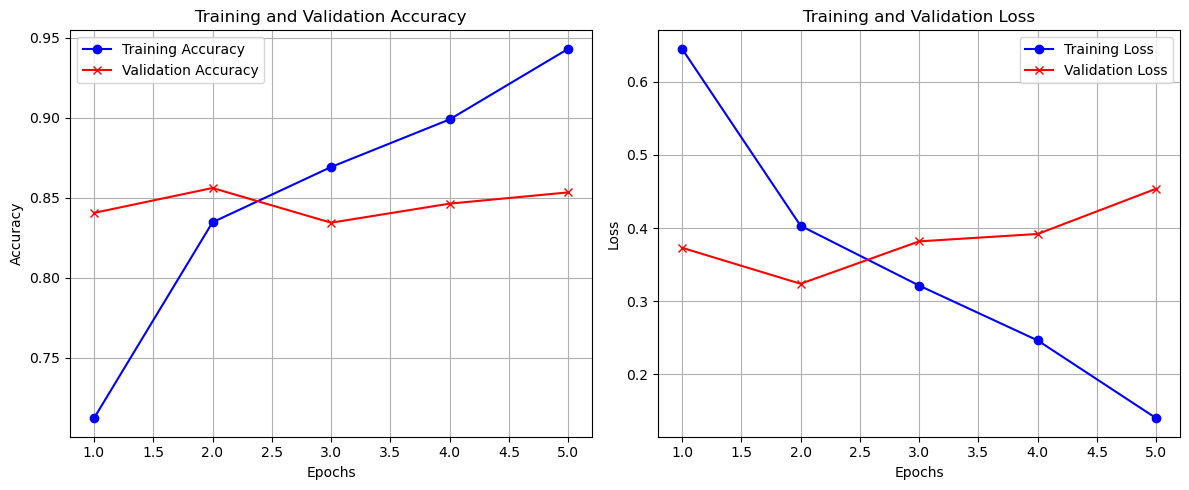

In [9]:
# =========================================================================
# 8. VẼ BIỂU ĐỒ (TRAINING CURVES) - ĐÁP ỨNG YÊU CẦU BÁO CÁO
# =========================================================================
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Biểu đồ Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='red', marker='x')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Biểu đồ Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='blue', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='red', marker='x')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)

103/103 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step


       KẾT QUẢ MÔ HÌNH TRÊN TẬP TEST
METRIC                    | VALUE          
---------------------------------------------
Test Loss                 | 0.3746
Test Accuracy             | 83.44%
Macro F1-Score            | 0.8034

📝 BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT):
                precision    recall  f1-score   support

  Tiêu cực (0)       0.93      0.79      0.86       622
  Tích cực (1)       0.92      0.88      0.90      1981
Trung tính (2)       0.59      0.75      0.66       669

      accuracy                           0.83      3272
     macro avg       0.81      0.81      0.80      3272
  weighted avg       0.85      0.83      0.84      3272



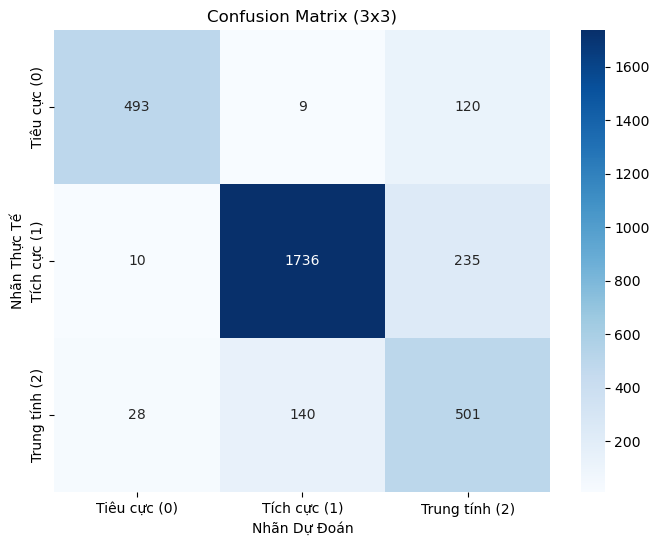

In [10]:
# =========================================================================
# 8. ĐÁNH GIÁ TỔNG THỂ TRÊN TẬP TEST (LOSS, ACCURACY, F1 & CONFUSION MATRIX)
# =========================================================================

# 1. Tính toán các chỉ số cơ bản (Loss & Accuracy)
test_results = model.evaluate(X_test_pad, y_test, verbose=0)
test_loss = test_results[0]
test_accuracy = test_results[1]

# 2. Dự đoán nhãn để tính F1 và vẽ Confusion Matrix
y_pred_prob = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
macro_f1 = f1_score(y_test, y_pred, average='macro')

# 3. In Bảng Tổng Kết (Dùng cho báo cáo nhanh)
print("\n")
print("       KẾT QUẢ MÔ HÌNH TRÊN TẬP TEST")
print("="*45)
print(f"{'METRIC':<25} | {'VALUE':<15}")
print("-" * 45)
print(f"{'Test Loss':<25} | {test_loss:.4f}")
print(f"{'Test Accuracy':<25} | {test_accuracy*100:.2f}%")
print(f"{'Macro F1-Score':<25} | {macro_f1:.4f}")
print("="*45)

# 4. In Báo Cáo Phân Loại Chi Tiết (Precision, Recall cho từng nhãn)
print("\n📝 BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT):")
target_names = ['Tiêu cực (0)', 'Tích cực (1)', 'Trung tính (2)']
print(classification_report(y_test, y_pred, target_names=target_names))

# 5. Vẽ Confusion Matrix (Kích thước 3x3)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Tiêu cực (0)', 'Tích cực (1)', 'Trung tính (2)'], 
            yticklabels=['Tiêu cực (0)', 'Tích cực (1)', 'Trung tính (2)'])
plt.title('Confusion Matrix (3x3)')
plt.xlabel('Nhãn Dự Đoán')
plt.ylabel('Nhãn Thực Tế')
plt.show()

In [ ]:
import pickle
import os
from huggingface_hub import HfApi, login

# --- CẤU HÌNH THÔNG TIN ---
# Dán token của bạn vào đây (Token phải có quyền WRITE)
HF_TOKEN = "" 
# Đã đổi tên repo từ svm sang bigru
REPO_NAME = "ltro6125/HCMUS-bigru-vietnamese-restaurant-sentiment-analysis" 

# --- BƯỚC 1: LƯU MÔ HÌNH VÀ TOKENIZER RA FILE LOCAL ---
print("1. Đang lưu mô hình và Tokenizer ra file local...")

model_name = "vietnamese-restaurant-bigru.keras"
tokenizer_name = "tokenizer.pkl"

# Lưu mô hình AI Keras
model.save(model_name)

# Lưu quyển từ điển Tokenizer
with open(tokenizer_name, 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Tạo file requirements.txt
with open("requirements_bigru.txt", "w") as f:
    f.write("tensorflow\nhuggingface_hub\npandas\nnumpy\npyvi\nscikit-learn\nmatplotlib\nseaborn")

# --- BƯỚC 2: ĐĂNG NHẬP VÀO HUGGING FACE ---
print("2. Đang đăng nhập vào Hugging Face...")
login(token=HF_TOKEN)

# --- BƯỚC 3: TẠO REPO VÀ PUSH FILE ---
api = HfApi()

print(f"3. Đang tạo/kiểm tra repository: {REPO_NAME}...")
api.create_repo(repo_id=REPO_NAME, repo_type="model", exist_ok=True)

# Danh sách các file cần upload của BiGRU model
files_to_upload = [model_name, tokenizer_name, "requirements_bigru.txt"]

print("4. Đang upload các file lên Hugging Face Hub...")
for file in files_to_upload:
    try:
        api.upload_file(
            path_or_fileobj=file,
            path_in_repo=file,
            repo_id=REPO_NAME,
            token=HF_TOKEN # Đảm bảo quyền ghi
        )
        print(f"   - Đã upload thành công: {file}")
    except Exception as e:
        print(f"   - Lỗi khi upload {file}: {e}")

print(f"\n--- HOÀN TẤT! ---")
print(f"Link mô hình: https://huggingface.co/{REPO_NAME}")


In [3]:
from huggingface_hub import HfApi, login

# --- CẤU HÌNH ---
HF_TOKEN = "***" 
REPO_NAME = "ltro6125/HCMUS-bigru-vietnamese-restaurant-sentiment-analysis" 

print("1. Đang đăng nhập vào Hugging Face...")
login(token=HF_TOKEN)

api = HfApi()

print(f"2. Bắt đầu đẩy dữ liệu vào Repo: {REPO_NAME}...")
api.create_repo(repo_id=REPO_NAME, repo_type="model", exist_ok=True)

# Đọc thẳng các file BẠN CÒN GIỮ trong ổ cứng
files_to_upload = ["vietnamese-restaurant-bigru.keras", "tokenizer.pkl", "requirements_bigru.txt"]

print("3. Bắt đầu quá trình Upload...")
for file in files_to_upload:
    try:
        api.upload_file(
            path_or_fileobj=file,
            path_in_repo=file,
            repo_id=REPO_NAME,
            token=HF_TOKEN
        )
        print(f"   -> Đã upload thành công: {file}")
    except Exception as e:
        print(f"   -> Lỗi tại {file}: {e}")

print(f"\n--- HOÀN TẤT ---")
print(f"Link mô hình: https://huggingface.co/{REPO_NAME}")

1. Đang đăng nhập vào Hugging Face...
2. Bắt đầu đẩy dữ liệu vào Repo: ltro6125/HCMUS-bigru-vietnamese-restaurant-sentiment-analysis...
3. Bắt đầu quá trình Upload...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

   -> Đã upload thành công: vietnamese-restaurant-bigru.keras


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

   -> Đã upload thành công: tokenizer.pkl
   -> Đã upload thành công: requirements_bigru.txt

--- HOÀN TẤT ---
Link mô hình: https://huggingface.co/ltro6125/HCMUS-bigru-vietnamese-restaurant-sentiment-analysis
